## UCS (Busca de Custo Uniforme)
> Conceito: Para grafos com arestas de valores não negativos o algoritmo de busca de custo uniforme se assemelha muito ao algoritmo **Dijkstra**, pois conceitualmente ambos implementam uma fila de prioriade a qual guarda os valores dos nós com o menor custo acumulado, assim achando o caminho ótimo 

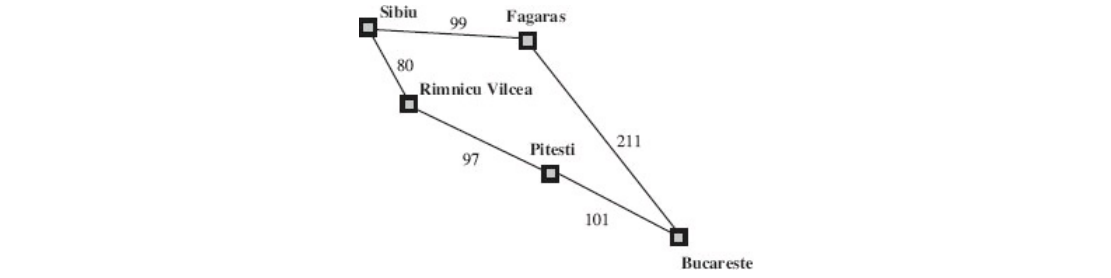

### Exemplo, digamos que queremos ir de **Sibiu** a **Bucareste**:
1. O nó a ser exepnadido será Rimnicu Vilcea, pois é de menor custo (80)
2. Após isso será o nó Pitesti (97)
3. Assim o custo toal fica em 177 (80+97)
4. Logo é retornado para Sibiu e expandido o nó Fagaras (99)
5. De Fagaras é expandido a Bucareste (Custo total de 310)
6. É retornado para sibiu e seguido Rimnicu Vilcea -> Pitesti -> Bucareste (Custo total de 278)
7. Mesmo o nó objetivo tendo sido alcançado ele testa um segundo caminho a fim de verificar qual tem o custo toal menor, assim descartando o primeiro caminho e mantendo o segundo de menor custo total

---

In [3]:
import networkx as nx
from grafo_romenia import criar_grafo_romenia

G = criar_grafo_romenia()

In [12]:
no_raiz = 'Sibiu'
no_objetivo = 'Bucharest'

caminho = nx.dijkstra_path(G, no_raiz, no_objetivo, weight="peso")
print(f"O caminho de menor custo de {no_raiz} para {no_objetivo} é: {caminho}")
custo = nx.dijkstra_path_length(G, source=no_raiz, target=no_objetivo, weight='peso')
print(f"O custo total do caminho é: {custo}")

O caminho de menor custo de Sibiu para Bucharest é: ['Sibiu', 'Rimnicu', 'Pitesti', 'Bucharest']
O custo total do caminho é: 278


---
### Vizualisação do caminho selecionado:

In [13]:
arestas_caminho = list(zip(caminho, caminho[1:]))
pos = nx.get_node_attributes(G, 'pos')


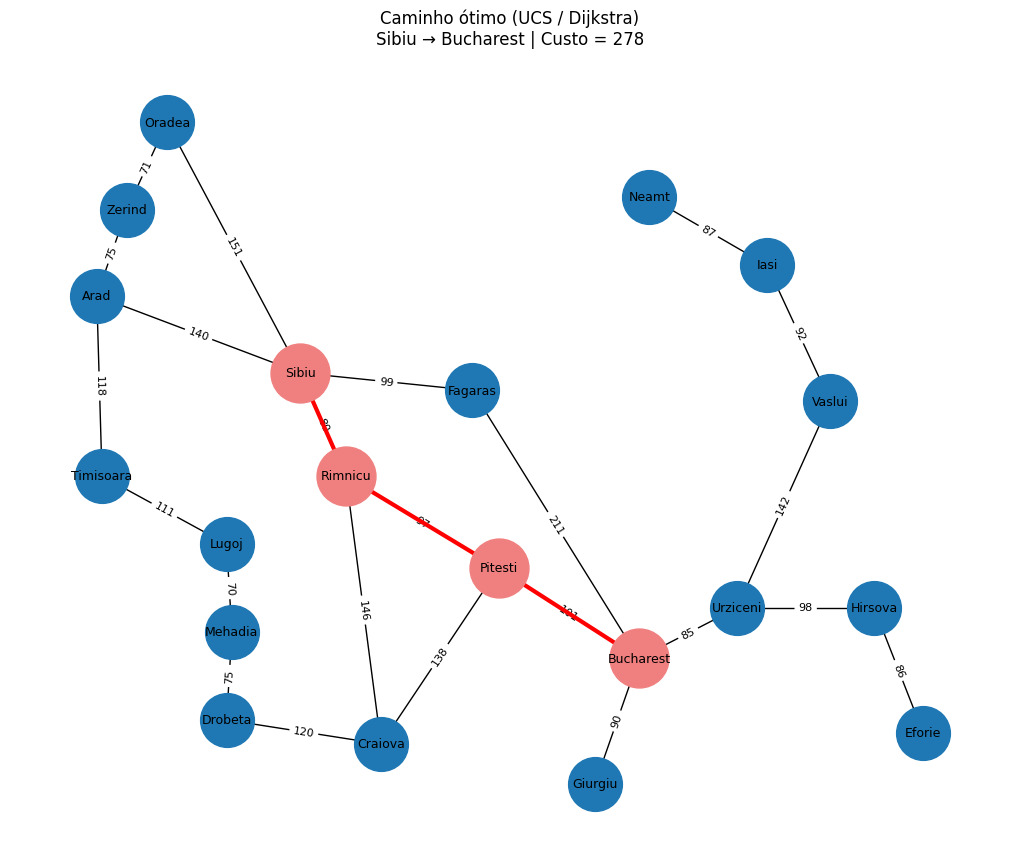

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# Grafo completo
nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=1500,
    font_size=9
)

# Pesos das arestas
edge_labels = nx.get_edge_attributes(G, 'peso')
nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_size=8
)

# Caminho ótimo destacado
nx.draw_networkx_edges(
    G,
    pos,
    edgelist=arestas_caminho,
    width=3,
    edge_color='red'
)

# Nós do caminho em destaque
nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=caminho,
    node_color='lightcoral',
    node_size=1800
)

plt.title(
    f"Caminho ótimo (UCS / Dijkstra)\n"
    f"{no_raiz} → {no_objetivo} | Custo = {custo}"
)

plt.show()
